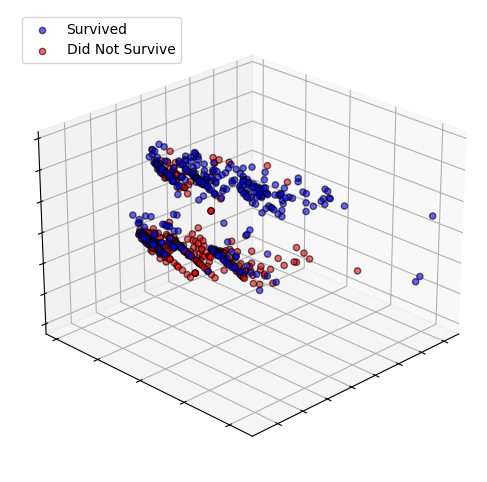

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn import decomposition
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
import pandas as pd

df = pd.read_csv("titanic-train.csv")

# Target Value
y = df["Survived"].values

# Encode Male/Female values
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

# Only keep numerical columns
df = df.drop(columns=["Survived", "PassengerId"])
df = df.select_dtypes(include=[np.number])

# Insert the mean for columns with missing data
df = df.fillna(df.mean())

# Feature values are all remaining number columns
X = df.values

# Standardize the feature values
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Perform Principle Component Analysis
pca = decomposition.PCA(n_components=3)
pca.fit(X)
X = pca.transform(X)

# Create the 3D plot
fig = plt.figure(1, figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d', elev=25, azim=225)

# Show the two groups separately
survived = X[y == 1]
did_not_survive = X[y == 0]

ax.scatter(survived[:, 0], survived[:, 1], survived[:, 2],
           c='blue', label='Survived', edgecolor='k', alpha=0.6)

ax.scatter(did_not_survive[:, 0], did_not_survive[:, 1], did_not_survive[:, 2],
           c='red', label='Did Not Survive', edgecolor='k', alpha=0.6)

ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])

ax.legend(loc='upper left')
plt.show()